In [ ]:
# Import Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

In [ ]:
# Data Airline Passengers
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
data = pd.read_csv(url)

data.head()

,Month,Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


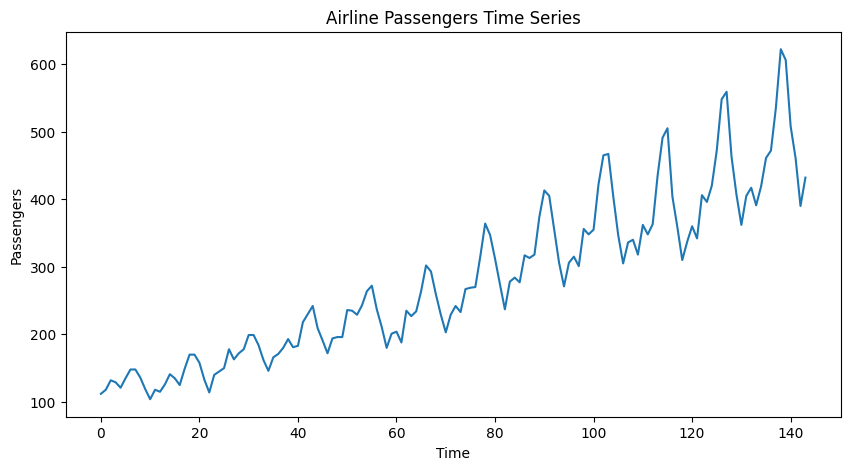

In [ ]:
# Plot passenger time series
plt.figure(figsize=(10,5))
plt.plot(data["Passengers"])
plt.title("Airline Passengers Time Series")
plt.xlabel("Time")
plt.ylabel("Passengers")
plt.show()

In [ ]:
# Normalization
values = data["Passengers"].values.reshape(-1,1)

scaler = MinMaxScaler(feature_range=(0,1))
values_scaled = scaler.fit_transform(values)

In [ ]:
# Sequences for LSTM
def create_sequences(data, seq_length):
    X = []
    y = []

    for i in range(len(data)-seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])

    return np.array(X), np.array(y)

sequence_length = 10

X, y = create_sequences(values_scaled, sequence_length)

print(X.shape, y.shape)

(134, 10, 1) (134, 1)


In [ ]:
# Train-Test Split
split = int(len(X)*0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

In [ ]:
# Build the LSTM Model
model = Sequential()

model.add(LSTM(50, activation='relu', input_shape=(sequence_length,1)))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mse')

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=8,
    validation_data=(X_test, y_test)
)

Epoch 1/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 0.1118 - val_loss: 0.3572
Epoch 2/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0636 - val_loss: 0.1924
Epoch 3/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0248 - val_loss: 0.0493
Epoch 4/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0148 - val_loss: 0.0345
Epoch 5/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0115 - val_loss: 0.0366
Epoch 6/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0096 - val_loss: 0.0251
Epoch 7/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0078 - val_loss: 0.0249
Epoch 8/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0073 - val_loss: 0.0276
Epoch 9/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0079 - val_loss: 0.0242
Epoch 10/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0075 - val_loss: 0.0239
Epoch 11/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0072 - val_loss: 0.0242
Epoch 12/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0

In [ ]:
# Predictions
predictions = model.predict(X_test)

predictions = scaler.inverse_transform(predictions)
y_test_actual = scaler.inverse_transform(y_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step


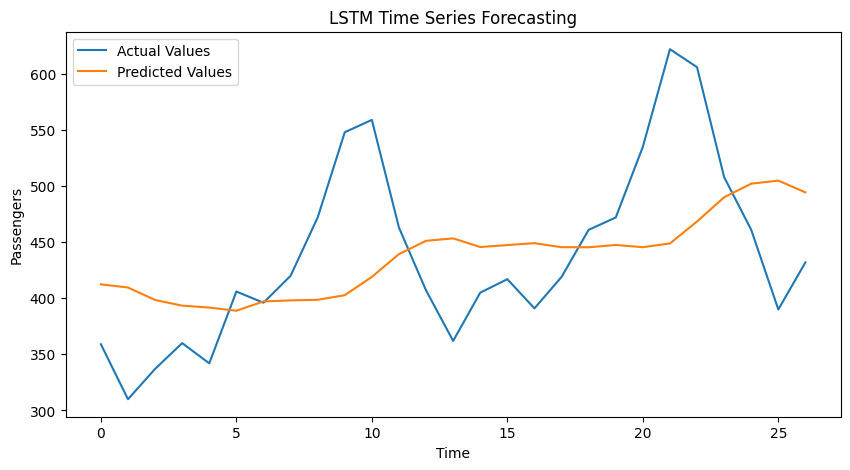

In [ ]:
# Visualization
plt.figure(figsize=(10,5))

plt.plot(y_test_actual, label="Actual Values")
plt.plot(predictions, label="Predicted Values")

plt.title("LSTM Time Series Forecasting")
plt.xlabel("Time")
plt.ylabel("Passengers")
plt.legend()

plt.show()